## Hypothesis Testing: Impact of Musical Features on Streams

## Import python libraries and download cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt

# Đọc luôn file dữ liệu SẠCH từ thư mục processed của bạn nhóm
# Dùng đường dẫn tương đối này thì ai trong nhóm mở máy lên cũng chạy được
df = pd.read_csv("../datasets/processed/cleaned_spotify_2023.csv")

# Xem qua các thông số trung bình, lớn nhất, nhỏ nhất
df[["danceability_%", "energy_%", "streams"]].describe()

,danceability_%,energy_%,streams
count,952.000000,952.000000,9.520000e+02
mean,66.984244,64.274160,5.141374e+08
std,14.631282,16.558517,5.668569e+08
min,23.000000,9.000000,2.762000e+03
25%,57.000000,53.000000,1.416362e+08
50%,69.000000,66.000000,2.905309e+08
75%,78.000000,77.000000,6.738690e+08
max,96.000000,97.000000,3.703895e+09


### Correlation Analysis (Heatmap)

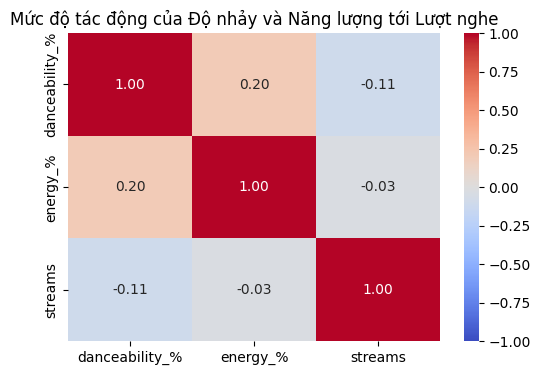

In [2]:
# Tính ma trận tương quan giữa 3 chỉ số chính
corr = df[["danceability_%", "energy_%", "streams"]].corr()

# Vẽ biểu đồ nhiệt dạng bảng màu cực đẹp
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Mức độ tác động của Độ nhảy và Năng lượng tới Lượt nghe")
plt.show()

### Trend and Regression Analysis

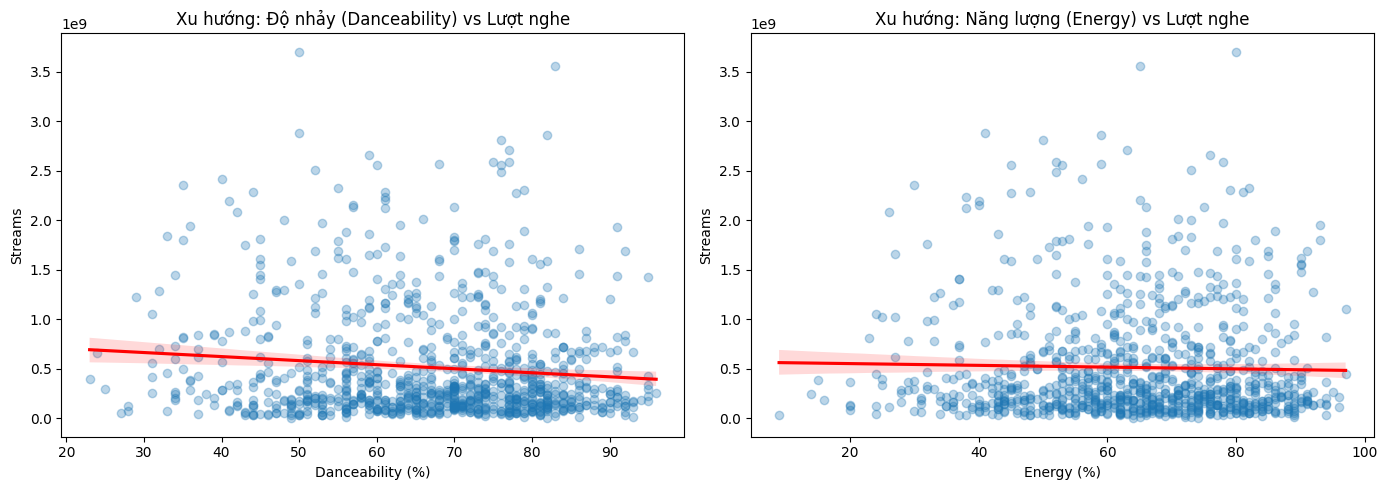

In [3]:
plt.figure(figsize=(14, 5))

# Biểu đồ bên trái: Độ nhảy vs Lượt nghe
plt.subplot(1, 2, 1)
sns.regplot(data=df, x="danceability_%", y="streams", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Xu hướng: Độ nhảy (Danceability) vs Lượt nghe")
plt.xlabel("Danceability (%)")
plt.ylabel("Streams")

# Biểu đồ bên phải: Năng lượng vs Lượt nghe
plt.subplot(1, 2, 2)
sns.regplot(data=df, x="energy_%", y="streams", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Xu hướng: Năng lượng (Energy) vs Lượt nghe")
plt.xlabel("Energy (%)")
plt.ylabel("Streams")

plt.tight_layout()
plt.show()

### Data Binning and Group Comparison

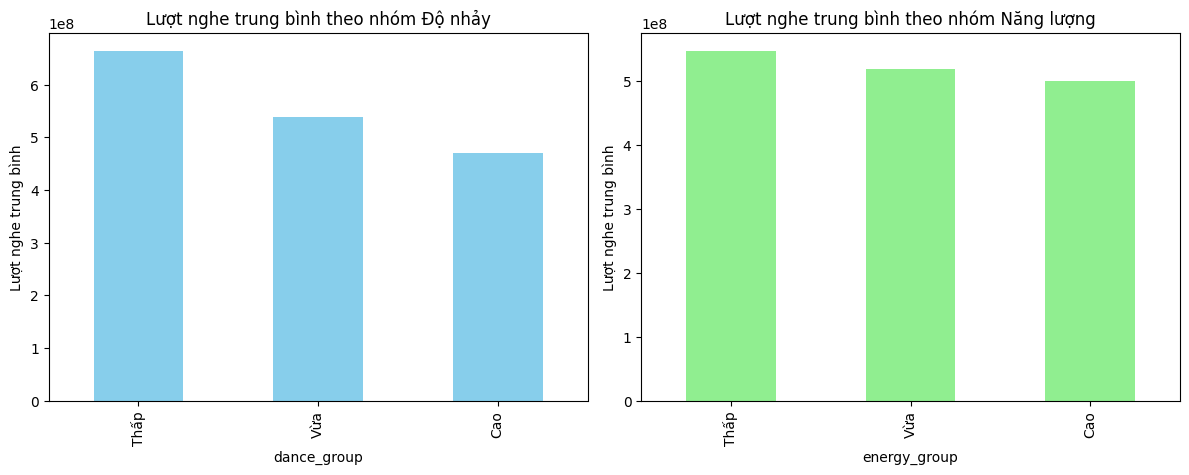

In [4]:
# 1. Chia nhóm cho cột Độ nhảy
df["dance_group"] = pd.cut(df["danceability_%"], bins=[0, 40, 70, 100], labels=["Thấp", "Vừa", "Cao"])

# 2. Chia nhóm cho cột Năng lượng
df["energy_group"] = pd.cut(df["energy_%"], bins=[0, 40, 70, 100], labels=["Thấp", "Vừa", "Cao"])

# 3. Vẽ 2 biểu đồ cột so sánh lượt nghe trung bình
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df.groupby("dance_group")["streams"].mean().plot(kind="bar", color="skyblue")
plt.title("Lượt nghe trung bình theo nhóm Độ nhảy")
plt.ylabel("Lượt nghe trung bình")

plt.subplot(1, 2, 2)
df.groupby("energy_group")["streams"].mean().plot(kind="bar", color="lightgreen")
plt.title("Lượt nghe trung bình theo nhóm Năng lượng")
plt.ylabel("Lượt nghe trung bình")

plt.tight_layout()
plt.show()

### Kiểm định Độ nhảy (Danceability)

In [5]:
import pandas as pd
from scipy import stats

# Đọc dữ liệu sạch
df = pd.read_csv("../datasets/processed/cleaned_spotify_2023.csv")

print("=== KIỂM ĐỊNH 1: ĐỘ NHẢY (DANCEABILITY) ===")
nhom_dance_cao = df[df["danceability_%"] > 70]["streams"].dropna()
nhom_dance_thap = df[df["danceability_%"] <= 70]["streams"].dropna()

t_stat1, p_value1 = stats.ttest_ind(nhom_dance_cao, nhom_dance_thap, equal_var=False)
p_val1 = p_value1 / 2

print(f"T-statistic: {t_stat1:.4f} | P-value: {p_val1:.4f}")
if p_val1 < 0.05 and t_stat1 > 0:
    print("=> Kết luận: Nhạc dễ nhảy (Danceability > 70%) thực sự có lượt nghe cao hơn rõ rệt!")
else:
    print("=> Kết luận: Không có sự khác biệt rõ rệt về lượt nghe.")

=== KIỂM ĐỊNH 1: ĐỘ NHẢY (DANCEABILITY) ===
T-statistic: -2.2022 | P-value: 0.0139
=> Kết luận: Không có sự khác biệt rõ rệt về lượt nghe.


### Kiểm định Năng lượng (Energy)

In [6]:
print("\n=== KIỂM ĐỊNH 2: NĂNG LƯỢNG (ENERGY) ===")
nhom_energy_cao = df[df["energy_%"] > 70]["streams"].dropna()
nhom_energy_thap = df[df["energy_%"] <= 70]["streams"].dropna()

t_stat2, p_value2 = stats.ttest_ind(nhom_energy_cao, nhom_energy_thap, equal_var=False)
p_val2 = p_value2 / 2

print(f"T-statistic: {t_stat2:.4f} | P-value: {p_val2:.4f}")
if p_val2 < 0.05 and t_stat2 > 0:
    print("=> Kết luận: Nhạc sôi động (Energy > 70%) thực sự có lượt nghe cao hơn rõ rệt!")
else:
    print("=> Kết luận: Không có sự khác biệt rõ rệt về lượt nghe giữa nhạc sôi động và nhạc nhẹ.")


=== KIỂM ĐỊNH 2: NĂNG LƯỢNG (ENERGY) ===
T-statistic: -0.6175 | P-value: 0.2685
=> Kết luận: Không có sự khác biệt rõ rệt về lượt nghe giữa nhạc sôi động và nhạc nhẹ.
